# SOURCE -
About Dataset
Extraction was done by Barry Becker from the 1994 Census database.
Prediction task is to determine whether a person makes over 50K a year.

Columns are:
age: continuous.
workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
fnlwgt: continuous.
education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
education-num: continuous.
marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
* sex: Female, Male.
* capital-gain: continuous.
* capital-loss: continuous.
hours-per-week: continuous.
native-country: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.
salary: <=50K or >50K
* **Source**: https://archive.ics.uci.edu/ml/datasets/Census+Income
* **Thumbnail**: https://www.deskera.com/blog/net-salary/

In [16]:
# Importing important libraries -
import pandas as pd
import numpy as np 
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# Loading the data
df = pd.read_csv('salary.csv')
print(df.head())

   age          workclass  fnlwgt   education  education-num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital-status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital-gain  capital-loss  hours-per-week  native-country  salary  
0          2174             0              40   United-States   <=50

# INTRODUCTION
* **Meaning of education number** -
* Preschool - 1
* 1st–4th - 2
* 5th–6th - 3
* 7th–8th - 4
* 9th - 5
* 10th - 6
* 11th - 7
* 12th - 8
* HS-grad (High School Graduate) - 9
* Some-college - 10
* Assoc-voc (Associate Vocational) - 11
* Assoc-acdm (Associate Academic) - 12
* Bachelors - 13
* Masters - 14
* Prof-school (Professional School, e.g., MD, Law) - 15
* Doctorate - 16

* **fnlwgt** -
In the UCI Adult / Census Income dataset, fnlwgt stands for Final Weight (or sample weight).
What It Represents
It is a statistical weight assigned by the U.S. Census Bureau. It represents the number of people in the overall U.S. population that a specific row (person) in the dataset represents, based on demographic characteristics (such as age, sex, race, and region).

* **salary** -- their salary is in wether it is less or equal than 50k or more than 50k , Which means there are only 2 possiblities 

In [18]:
# Checking if there is any null value or wrong data type in data using info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  salary          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.5 MB


In [19]:
# All data types are correct except salary which is in string , There is no empty input

In [20]:
# Now we will use statatics to check the wrong inputs (if there are any)
print(df.describe().round(2))

            age      fnlwgt  education-num  capital-gain  capital-loss  \
count  32561.00    32561.00       32561.00      32561.00      32561.00   
mean      38.58   189778.37          10.08       1077.65         87.30   
std       13.64   105549.98           2.57       7385.29        402.96   
min       17.00    12285.00           1.00          0.00          0.00   
25%       28.00   117827.00           9.00          0.00          0.00   
50%       37.00   178356.00          10.00          0.00          0.00   
75%       48.00   237051.00          12.00          0.00          0.00   
max       90.00  1484705.00          16.00      99999.00       4356.00   

       hours-per-week  
count        32561.00  
mean            40.44  
std             12.35  
min              1.00  
25%             40.00  
50%             40.00  
75%             45.00  
max             99.00  


# Analysis :
* There is a person who is 17 year old sowing there are minors too 
* the capital gain maximum is a little suspicious
* the maximum hours per week is 99 hours which is too muh for average

# Pandas 

In [21]:
# For some key infos in data
sus_capital_gain = (df['capital-gain'] == 99999).sum()
minors = (df['age'] < 18).sum()
overwork = (df['hours-per-week'] > 44).sum()
education = df['education'].value_counts()
martial = df['marital-status'].value_counts()
workclass = df['workclass'].value_counts()

print('Capital gain of 99k :',sus_capital_gain)
print('People with age less than 18 :',minors)
print('People doing work more than average hours per week :',overwork)
print(education)
print(martial)
print(workclass)

Capital gain of 99k : 159
People with age less than 18 : 395
People doing work more than average hours per week : 8963
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64
marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked     

# Pandas insights
* **Marital Status,Count,Percentage
Married (Civilian Spouse)**,"14,976",~46.0%
Never Married,"10,683",~32.8%
Divorced / Separated / Widowed,"6,461",~19.8%
Married (Spouse Absent / Armed Forces),441,~1.4

* **Education Level,Count,Percentage**
High School Graduates (HS-grad),"10,501",~32.2%
Some College,"7,291",~22.4%
Bachelors,"5,355",~16.4%
"Higher Degrees (Masters, Doctorate, Prof-school)","2,712",~8.3%
Associate Degrees (Vocational & Academic),"2,449",~7.5%
"K-12 non-completers & Below (1st–12th, Preschool)","4,253",~13.1%

* **Workclass** - Highest number of peoples are working in the private sector : 22696

# SQL

In [22]:
# Connecting sql with the data
conn = sqlite3.connect('salary.db')
df.to_sql('salary_data',conn,index = False , if_exists = 'replace')

32561

In [23]:
# Each query will answer a question or a key point

# Question 1 - Who have the highest hours per week male or female
query1 = 'SELECT "sex" , AVG("hours-per-week") as avg_hour FROM salary_data GROUP BY sex ORDER BY avg_hour DESC'
print(pd.read_sql_query(query1,conn))

#Question2 - Who have the highest fnlwgt male or female
query2 = 'SELECT "sex" , AVG("fnlwgt") as avg_fnlwgt FROM salary_data GROUP BY sex ORDER BY avg_fnlwgt DESC'
print(pd.read_sql_query(query2,conn))

# Question 3 - People with the education level less or equal than 12th grade
query3 = ' SELECT "education-num"  FROM salary_data WHERE "education-num" < 14'
print('Number of people with education level less or equal to 12th grade :',len(pd.read_sql_query(query3,conn)))

# Question4 - Number of people with salary less than and more than 50k 
print(df['salary'].value_counts())

       sex   avg_hour
0     Male  42.428086
1   Female  36.410361
       sex     avg_fnlwgt
0     Male  191771.449013
1   Female  185746.311206
Number of people with education level less or equal to 12th grade : 29849
salary
<=50K    24720
>50K      7841
Name: count, dtype: int64


# SQL INSIGHTS

# Sql insights :
* Males have more average work hours per week than womens , males : 42 , female  36
* Number of peoples with less education than 12th grade is : 29849
* <=50K  :  24720 , >50K   :   7841

# PLOTTING

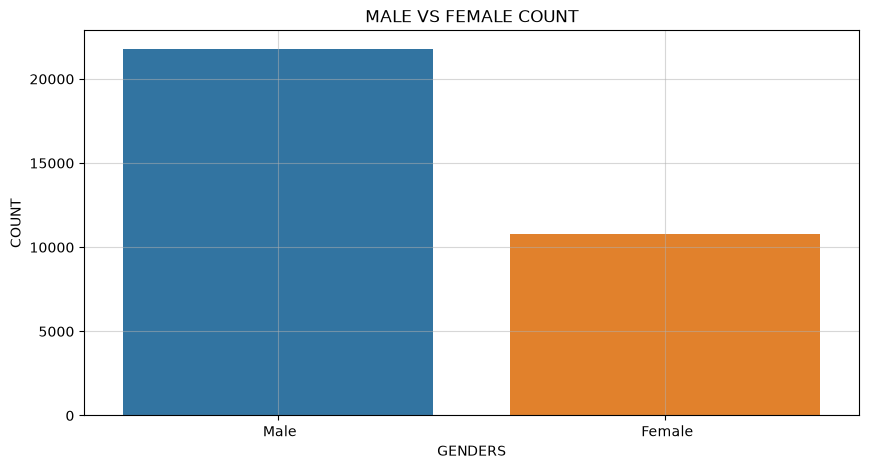

In [24]:
# MALE VS FEMALE BAR PLOT
plt.figure(figsize = (10,5))
sns.countplot(data = df , x = 'sex' , hue = 'sex')
plt.title('MALE VS FEMALE COUNT')
plt.xlabel('GENDERS')
plt.ylabel('COUNT')
plt.grid(True,alpha = 0.5)
plt.show()

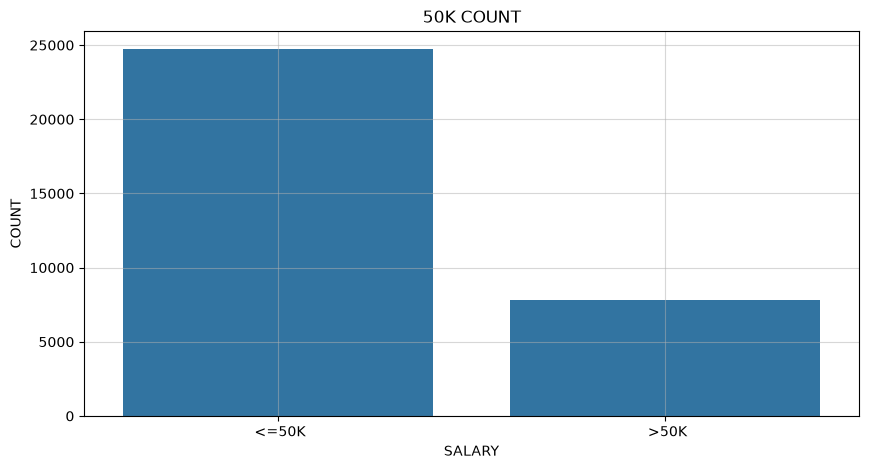

In [25]:
# SALARY BAR PLOT
plt.figure(figsize = (10,5))
sns.countplot(data = df , x = 'salary')
plt.title('50K COUNT')
plt.xlabel('SALARY')
plt.ylabel('COUNT')
plt.grid(True,alpha = 0.5)
plt.show()

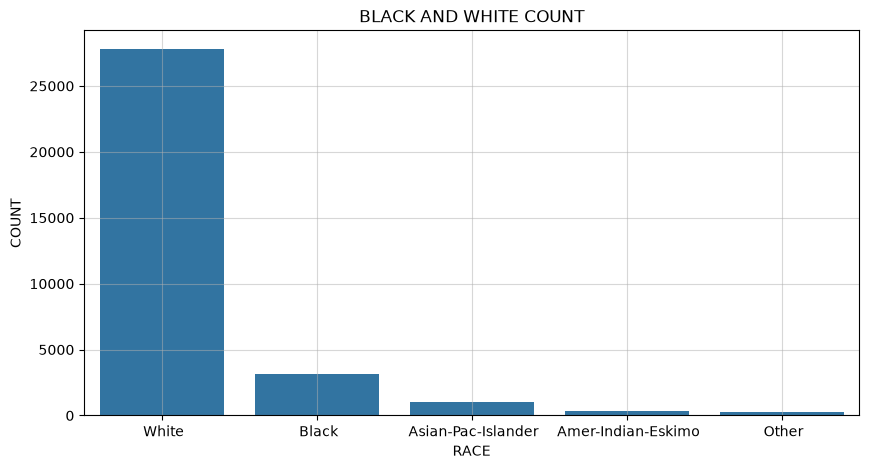

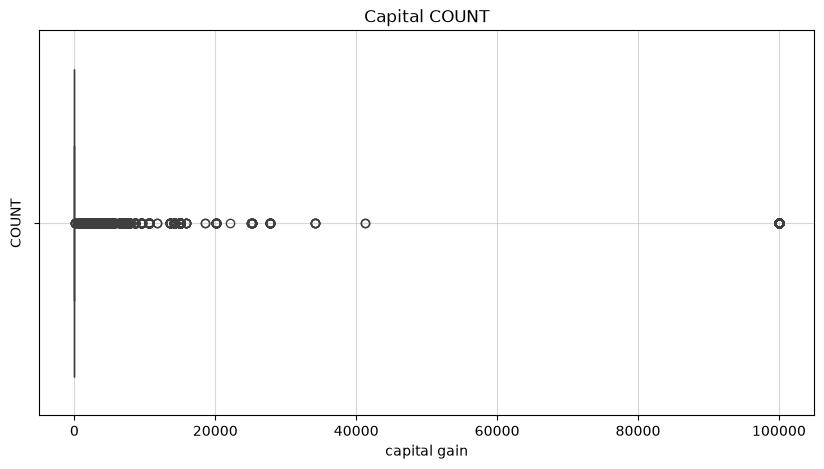

In [26]:
# RACE BAR PLOT
plt.figure(figsize = (10,5))
sns.countplot(data = df , x = 'race')
plt.title('BLACK AND WHITE COUNT')
plt.xlabel('RACE')
plt.ylabel('COUNT')
plt.grid(True,alpha = 0.5)
plt.show()

# box plot
plt.figure(figsize = (10,5))
sns.boxplot(data = df , x = 'capital-gain')
plt.title('Capital COUNT')
plt.xlabel('capital gain')
plt.ylabel('COUNT')
plt.grid(True,alpha = 0.5)
plt.show()


# CORRELATION

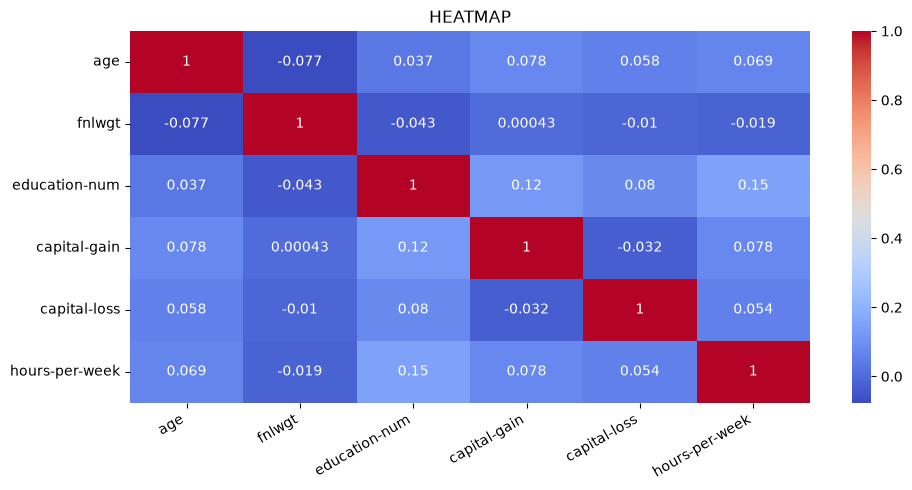

In [27]:
col = df.corr(numeric_only = True)

plt.figure(figsize = (10,5))
sns.heatmap(col , annot = True , cmap = 'coolwarm')
plt.title('HEATMAP')
plt.xticks(rotation = 390 , ha = 'right')
plt.tight_layout()

In [28]:
# Almost none of them relate to each other or  correlate 

# ML MODEL

In [35]:
# Machine learning model
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

In [36]:
x = df.drop(columns=['salary'])
y = df['salary'].str.strip().map({'<=50K':0 , '>50K':1})

x_encoded = pd.get_dummies(x, drop_first=True)

x_train, x_test, y_train, y_test = train_test_split(x_encoded,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

model = DecisionTreeClassifier(max_depth=10, random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))



precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:   ", recall)
print("F1-Score: ",f1)

Accuracy: 0.8595117457392907
Precision: 0.767536704730832
Recall:    0.5989815404201145
F1-Score:  0.6728637826242403


## Final Model Verdict & Evaluation

### Key Takeaways
* **Overall Accuracy (85.95%):** The Decision Tree classifier (`max_depth=10`) achieves strong overall performance on the test set.
* **Precision (76.75%):** When the model predicts that an individual earns `>50K`, it is correct **~77% of the time**, keeping false positive predictions low.
* **Recall (59.90%):** The model misses about **40% of actual high earners**, labeling them as `<=50K`. This stems from the class imbalance in the dataset (~75% earning `<=50K` vs ~25% earning `>50K`).
* **F1-Score (0.6729):** Demonstrates a solid balance between precision and recall for the minority positive class (`>50K`).

---


In [41]:
import pandas as pd
import joblib
from sklearn.tree import DecisionTreeClassifier

# 1. Load dataset
df = pd.read_csv('salary.csv')

# 2. Strip whitespace from string columns to prevent NaN mapping issues
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# 3. Separate Target and Features
y = df['salary'].map({'<=50K': 0, '>50K': 1})
X = df.drop(columns=['salary'])

# 4. One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# 5. Train Model
model = DecisionTreeClassifier(max_depth=10, random_state=42)
model.fit(X_encoded, y)

# 6. Save Model & Feature Schema using Joblib
joblib.dump(model, 'model.joblib')
joblib.dump(X_encoded.columns.tolist(), 'model_features.joblib')

print("✅ Saved model.joblib and model_features.joblib successfully!")

C:\Users\lenovo\AppData\Local\Temp\ipykernel_3872\2421045936.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


✅ Saved model.joblib and model_features.joblib successfully!
